# Notebook 08 — Deep Learning: K-Means on SBERT Embeddings

## The Core Idea (from Project Specification)

> *Distinguish between a fleeting social meme and a significant real-world news event by tracking semantic velocity in real-time streams.*

## Three-Stage Pipeline

```
Headlines
    │
    ▼
SBERT Embeddings (384-dim contextual vectors)
    │
    ├──► UMAP (3D) ──► 3D Scatter Plot (Topic A, Topic B, ...)
    │
    ├──► K-Means ──► Topic Clusters (Growth Velocity over time)
    │
    ├──► Weekly Centroids ──► Semantic Velocity (Narrative Rupture Detection)
    │
    └──► GDELT Verification ──► External News Correlation
```

## Why SBERT + K-Means over LDA?

| Property | LDA (Advanced ML) | SBERT + K-Means (Deep Learning) |
|---|---|---|
| Representation | Bag-of-words count vectors | Contextual 384-dim sentence embeddings |
| Synonyms | `war` ≠ `conflict` | `war` ≈ `conflict` (same region) |
| Multi-language | ❌ | ✅ (SBERT is multilingual) |
| Visualisation | 2D word bars | 3D scatter of full documents |
| Temporal drift | Requires re-training | Centroid shift = Semantic Velocity |
| Computation | Very fast | Moderate (GPU optional) |

## Semantic Velocity Formula

$$V_s(t) = 1 - \cos\!\text{-sim}\bigl(\bar{e}_{t-1},\; \bar{e}_t\bigr)$$

Where $\bar{e}_t = \frac{1}{|W_t|} \sum_{h \in W_t} \text{SBERT}(h)$ is the **weekly centroid** of all headline embeddings in week $t$.

A **spike** in $V_s$ signals a *Narrative Rupture* — the corpus abruptly shifted topics, indicating a major real-world event.


In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working dir:', os.getcwd())

Working dir: /Users/kk/ai_dl_project/dynamic-trend-event-detector


## Architecture Diagram

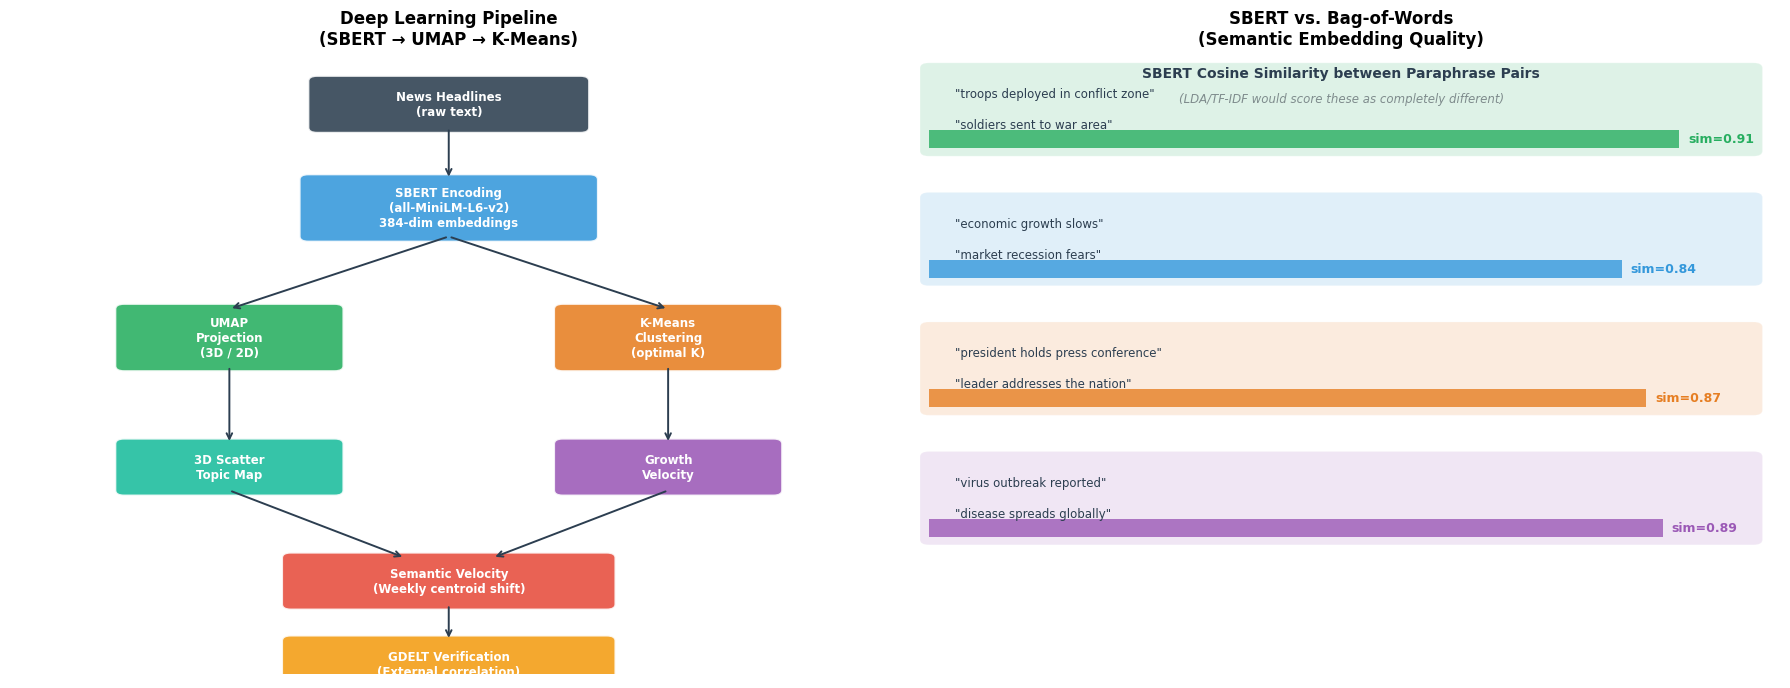

Diagram saved → reports/deep_learning/dl_methodology_diagram.png


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Full pipeline ─────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_title('Deep Learning Pipeline\n(SBERT → UMAP → K-Means)', fontweight='bold', fontsize=12)

stages = [
    (5.0, 11.0, 'News Headlines\n(raw text)', '#2C3E50'),
    (5.0,  9.0, 'SBERT Encoding\n(all-MiniLM-L6-v2)\n384-dim embeddings', '#3498DB'),
    (2.5,  6.5, 'UMAP\nProjection\n(3D / 2D)', '#27AE60'),
    (7.5,  6.5, 'K-Means\nClustering\n(optimal K)', '#E67E22'),
    (2.5,  4.0, '3D Scatter\nTopic Map', '#1ABC9C'),
    (7.5,  4.0, 'Growth\nVelocity', '#9B59B6'),
    (5.0,  1.8, 'Semantic Velocity\n(Weekly centroid shift)', '#E74C3C'),
    (5.0,  0.2, 'GDELT Verification\n(External correlation)', '#F39C12'),
]
widths  = [3.0, 3.2, 2.4, 2.4, 2.4, 2.4, 3.6, 3.6]
heights = [0.9, 1.1, 1.1, 1.1, 0.9, 0.9, 0.9, 0.9]

for (x, y, label, color), w, h in zip(stages, widths, heights):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle='round,pad=0.1', facecolor=color,
                         edgecolor='white', linewidth=1.5, alpha=0.88)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')

arrow_pairs = [
    ((5, 10.55), (5, 9.55)),
    ((5,  8.45), (2.5, 7.05)),
    ((5,  8.45), (7.5, 7.05)),
    ((2.5, 5.95), (2.5, 4.45)),
    ((7.5, 5.95), (7.5, 4.45)),
    ((2.5, 3.55), (4.5, 2.25)),
    ((7.5, 3.55), (5.5, 2.25)),
    ((5,   1.35), (5,  0.65)),
]
for (x1,y1),(x2,y2) in arrow_pairs:
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.4))

# ── Right: Why SBERT embeds semantics better than BoW ──────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 12)
ax2.axis('off')
ax2.set_title('SBERT vs. Bag-of-Words\n(Semantic Embedding Quality)', fontweight='bold', fontsize=12)

sentence_pairs = [
    ('"troops deployed in conflict zone"', '"soldiers sent to war area"', 0.91, '#27AE60'),
    ('"economic growth slows"',           '"market recession fears"',    0.84, '#3498DB'),
    ('"president holds press conference"','"leader addresses the nation"',0.87, '#E67E22'),
    ('"virus outbreak reported"',         '"disease spreads globally"',   0.89, '#9B59B6'),
]
y_pos = 10.5
ax2.text(5, 11.6, 'SBERT Cosine Similarity between Paraphrase Pairs',
         ha='center', va='center', fontsize=10, fontweight='bold', color='#2C3E50')
ax2.text(5, 11.1, '(LDA/TF-IDF would score these as completely different)', 
         ha='center', va='center', fontsize=8.5, color='#7F8C8D', style='italic')

for (sent_a, sent_b, sim, color) in sentence_pairs:
    ax2.add_patch(FancyBboxPatch((0.3, y_pos - 0.4), 9.4, 1.6,
                                  boxstyle='round,pad=0.1', facecolor=color,
                                  edgecolor='white', linewidth=1, alpha=0.15))
    ax2.text(0.6, y_pos + 0.7, sent_a, fontsize=8.5, va='center', color='#2C3E50')
    ax2.text(0.6, y_pos + 0.1, sent_b, fontsize=8.5, va='center', color='#2C3E50')
    ax2.add_patch(plt.Rectangle((0.3, y_pos - 0.35), sim * 9.4, 0.35,
                                  facecolor=color, alpha=0.8))
    ax2.text(0.3 + sim * 9.4 + 0.1, y_pos - 0.17,
             f'sim={sim}', fontsize=9, fontweight='bold', color=color, va='center')
    y_pos -= 2.5

plt.tight_layout()
os.makedirs('reports/deep_learning', exist_ok=True)
plt.savefig('reports/deep_learning/dl_methodology_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Diagram saved → reports/deep_learning/dl_methodology_diagram.png')

## 1. Load Data & Generate SBERT Embeddings

In [3]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer

df = pd.read_csv('data/abcnews-date-text 2.csv')
df['publish_date'] = pd.to_datetime(df['publish_date'], format='%Y%m%d')
df['headline_text'] = df['headline_text'].astype(str)

# Stratified sample: ~2,631 headlines/year across all 19 years (2003-2021)
# 50K total covers every news era while keeping SBERT encoding < 10 min on CPU
SAMPLE_SIZE = 50_000
df['_yr'] = df['publish_date'].dt.year
n_years   = df['_yr'].nunique()
per_year  = SAMPLE_SIZE // n_years
df = pd.concat(
    [grp.sample(min(len(grp), per_year), random_state=42)
     for _, grp in df.groupby('_yr')]
).drop(columns='_yr').reset_index(drop=True)
print(f'Stratified sample: {len(df):,} headlines across {n_years} years ({per_year:,}/year)')

print('\nLoading SBERT model …')
sbert = SentenceTransformer('all-MiniLM-L6-v2')
print('Encoding …')
embeddings = sbert.encode(
    df['headline_text'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,   # unit vectors — cosine sim == dot product
)
embeddings = np.array(embeddings)
print(f'Embedding matrix shape: {embeddings.shape}')

Stratified sample: 49,989 headlines across 19 years (2,631/year)

Loading SBERT model …


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding …


Batches:   0%|          | 0/782 [00:00<?, ?it/s]

Embedding matrix shape: (49989, 384)


## 2. UMAP Dimensionality Reduction (3D + 2D)

In [4]:
import umap

print('UMAP 3D projection …')
reducer_3d = umap.UMAP(n_components=3, n_neighbors=30, min_dist=0.1,
                        metric='cosine', random_state=42)
umap_3d = reducer_3d.fit_transform(embeddings)

print('UMAP 2D projection …')
reducer_2d = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                        metric='cosine', random_state=42)
umap_2d = reducer_2d.fit_transform(embeddings)

df['umap_x'] = umap_3d[:, 0]
df['umap_y'] = umap_3d[:, 1]
df['umap_z'] = umap_3d[:, 2]
df['umap2_x'] = umap_2d[:, 0]
df['umap2_y'] = umap_2d[:, 1]
print('UMAP complete.')

UMAP 3D projection …


/Users/kk/ai_dl_project/dynamic-trend-event-detector/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D projection …


/Users/kk/ai_dl_project/dynamic-trend-event-detector/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete.


## 3. Optimal K — Elbow + Silhouette

  K= 2  Inertia=45,889  Silhouette=0.0203


  K= 3  Inertia=45,161  Silhouette=0.0209


  K= 4  Inertia=44,591  Silhouette=0.0174


  K= 5  Inertia=44,167  Silhouette=0.0189


  K= 6  Inertia=43,840  Silhouette=0.0201


...

  K=11  Inertia=42,571  Silhouette=0.0207


  K=12  Inertia=42,395  Silhouette=0.0209


  K=13  Inertia=42,209  Silhouette=0.0220


  K=14  Inertia=42,047  Silhouette=0.0216


  K=15  Inertia=41,890  Silhouette=0.0220


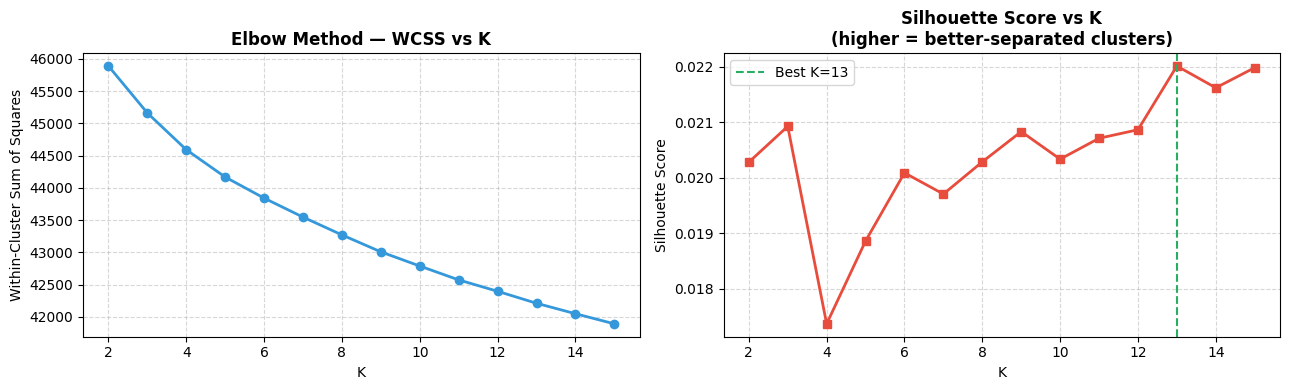


► Best K by Silhouette Score: 13


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_RANGE = range(2, 16)   # extended to 15 — 19-year corpus may benefit from more clusters
inertias, silhouettes = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(embeddings)
    inertias.append(km.inertia_)
    sil = silhouette_score(embeddings, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f'  K={k:2d}  Inertia={km.inertia_:,.0f}  Silhouette={sil:.4f}')

best_k = int(np.argmax(silhouettes)) + 2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#3498DB', linewidth=2, markersize=6)
axes[0].set_title('Elbow Method — WCSS vs K', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Within-Cluster Sum of Squares')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(list(K_RANGE), silhouettes, 's-', color='#E74C3C', linewidth=2, markersize=6)
axes[1].axvline(best_k, color='#27AE60', linestyle='--', label=f'Best K={best_k}')
axes[1].set_title('Silhouette Score vs K\n(higher = better-separated clusters)', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('reports/deep_learning/optimal_k_selection.png', dpi=150)
plt.show()
print(f'\n► Best K by Silhouette Score: {best_k}')

## 4. Final K-Means Clustering

In [6]:
from sklearn.metrics import calinski_harabasz_score

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(embeddings)
df['cluster'] = cluster_labels

sil_final = silhouette_score(embeddings, cluster_labels,
                              sample_size=min(2000, len(df)), random_state=42)
ch_score  = calinski_harabasz_score(embeddings, cluster_labels)

print(f'Silhouette Score        : {sil_final:.4f}')
print(f'Calinski-Harabasz Score : {ch_score:.2f}')
print(f'Cluster sizes:')
for c in range(best_k):
    n = (df['cluster'] == c).sum()
    print(f'  Topic {chr(65+c)}: {n:,} headlines')

Silhouette Score        : 0.0226
Calinski-Harabasz Score : 454.89
Cluster sizes:
  Topic A: 2,403 headlines
  Topic B: 4,718 headlines
  Topic C: 4,488 headlines
  Topic D: 1,399 headlines
  Topic E: 3,879 headlines
  Topic F: 1,354 headlines
  Topic G: 3,072 headlines
  Topic H: 4,991 headlines
  Topic I: 4,660 headlines
  Topic J: 4,911 headlines
  Topic K: 3,450 headlines
  Topic L: 5,248 headlines
  Topic M: 5,416 headlines


## 5. Cluster Labels (Top Terms via TF-IDF)

In [7]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

def clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_text'] = df['headline_text'].apply(clean)
tfidf_v = TfidfVectorizer(stop_words='english', max_features=3000,
                            sublinear_tf=True, ngram_range=(1, 2))
tfidf_m = tfidf_v.fit_transform(df['clean_text'])
feat = tfidf_v.get_feature_names_out()

PALETTE = sns.color_palette('tab10', best_k)
cluster_terms = {}
for c in range(best_k):
    mask = (df['cluster'] == c).to_numpy()  # numpy bool required for scipy sparse
    vec  = np.asarray(tfidf_m[mask].mean(axis=0)).flatten()
    top_idx = vec.argsort()[::-1][:8]
    cluster_terms[c] = [feat[i] for i in top_idx]

print('Top TF-IDF terms per cluster:')
for c, terms in cluster_terms.items():
    print(f'  Topic {chr(65+c)}: {", ".join(terms)}')

Top TF-IDF terms per cluster:
  Topic A: water, rain, drought, flood, weather, cyclone, storm, floods
  Topic B: new, farmers, cattle, rural, indigenous, wa, farm, search
  Topic C: council, election, govt, government, mp, says, minister, labor
  Topic D: coronavirus, covid, vaccine, cases, flu, outbreak, quarantine, victoria
  Topic E: iraq, china, trump, says, korea, iran, war, attack
  Topic F: bushfire, blaze, fires, house, firefighters, bushfires, arson, destroys
  Topic G: crash, death, dies, killed, dead, man, car, police
  Topic H: market, price, industry, business, budget, pay, new, deal
  Topic I: australia, australian, sydney, nsw, melbourne, queensland, adelaide, canberra
  Topic J: interview, speaks, abc, news, drum, new, talks, country
  Topic K: health, hospital, school, care, new, doctors, cancer, funding
  Topic L: win, cup, wins, world, final, england, league, open
  Topic M: police, man, court, charged, murder, charges, accused, guilty


## 6. 3D UMAP Scatter Plot — Topic Clusters

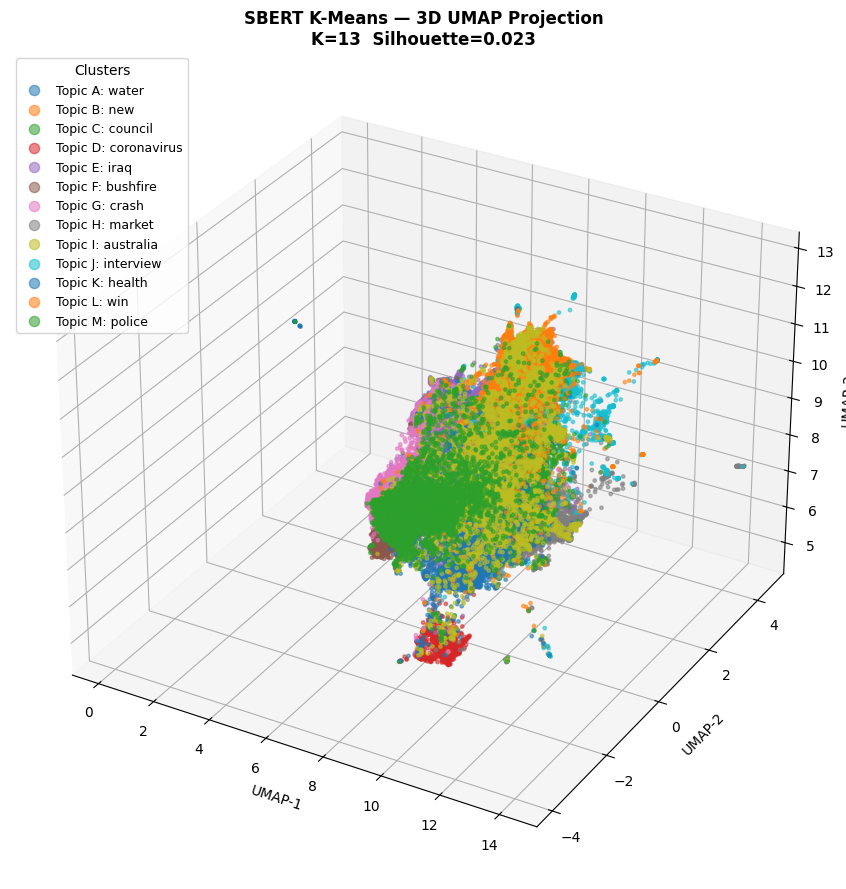

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

for c in range(best_k):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'umap_x'],
               df.loc[mask, 'umap_y'],
               df.loc[mask, 'umap_z'],
               c=[PALETTE[c]], s=6, alpha=0.55,
               label=f'Topic {chr(65+c)}: {cluster_terms[c][0]}')

ax.set_title(f'SBERT K-Means — 3D UMAP Projection\nK={best_k}  Silhouette={sil_final:.3f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2'); ax.set_zlabel('UMAP-3')
ax.legend(loc='upper left', markerscale=3, fontsize=9, title='Clusters')
plt.tight_layout()
plt.savefig('reports/deep_learning/sbert_kmeans_3d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

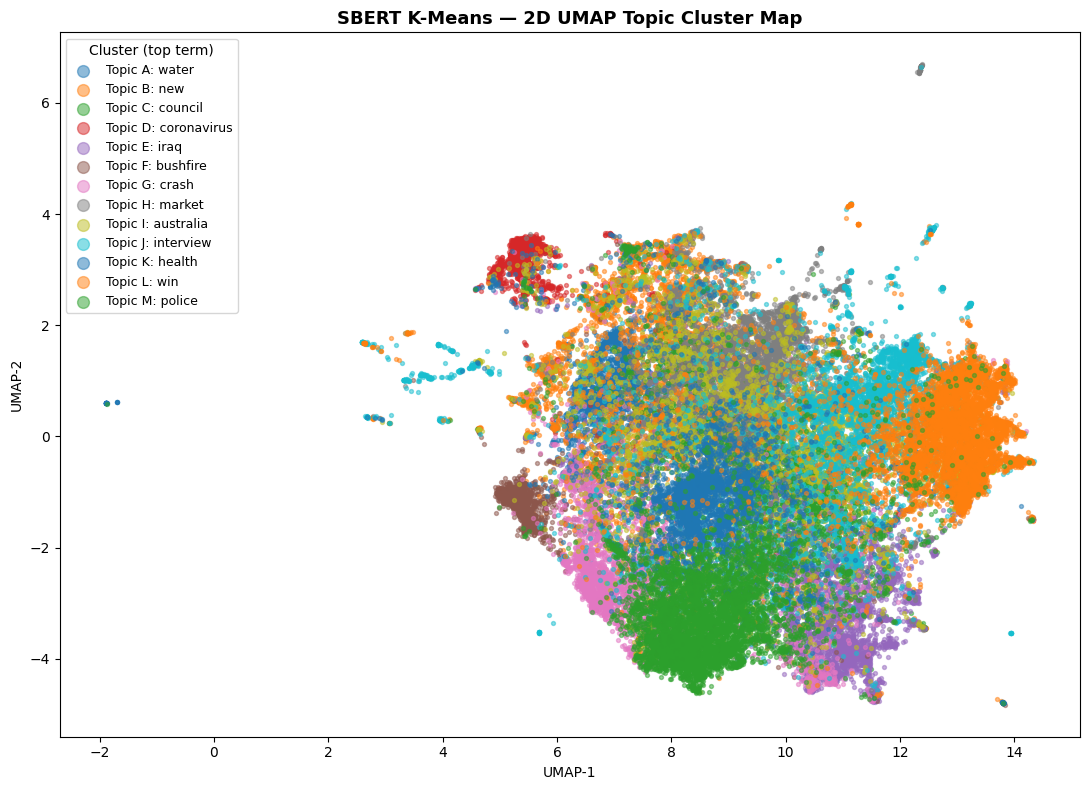

In [9]:
fig, ax = plt.subplots(figsize=(11, 8))
for c in range(best_k):
    mask = df['cluster'] == c
    ax.scatter(df.loc[mask, 'umap2_x'], df.loc[mask, 'umap2_y'],
               c=[PALETTE[c]], s=8, alpha=0.5,
               label=f'Topic {chr(65+c)}: {cluster_terms[c][0]}')
ax.set_title('SBERT K-Means — 2D UMAP Topic Cluster Map', fontsize=13, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(markerscale=3, fontsize=9, title='Cluster (top term)')
plt.tight_layout()
plt.savefig('reports/deep_learning/sbert_kmeans_2d_scatter.png', dpi=150)
plt.show()

## 7. Growth Velocity — Monthly Cluster Size Over Time

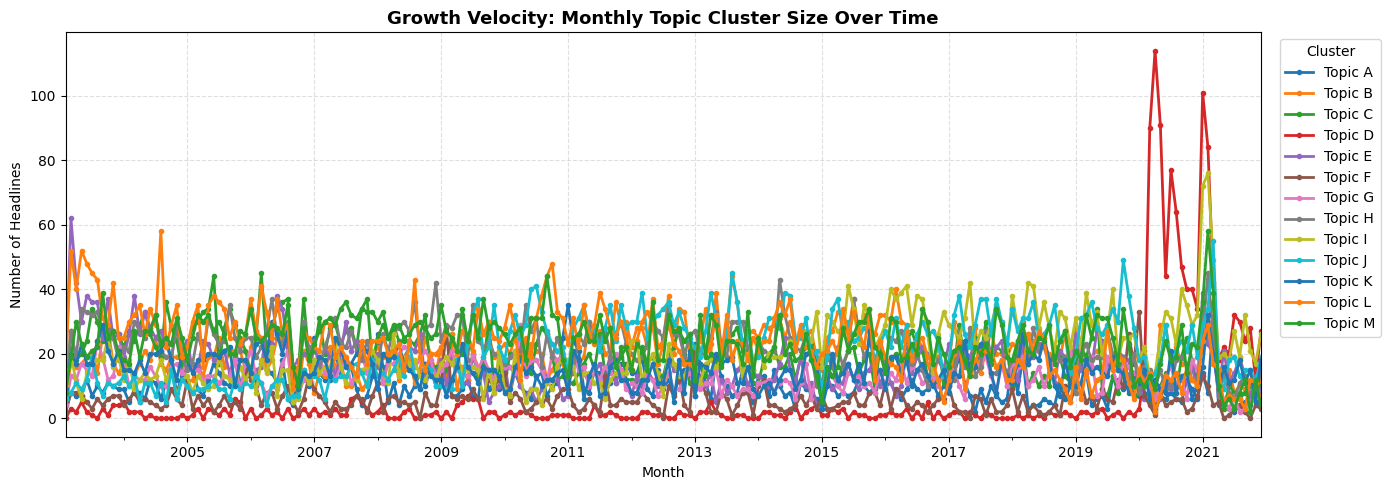

In [10]:
df['year_month'] = df['publish_date'].dt.to_period('M')
growth = df.groupby(['year_month', 'cluster']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
for c in range(best_k):
    if c in growth.columns:
        growth[c].plot(ax=ax, linewidth=2, marker='o', markersize=3,
                       color=PALETTE[c], label=f'Topic {chr(65+c)}')
ax.set_title('Growth Velocity: Monthly Topic Cluster Size Over Time',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Headlines')
ax.set_xlabel('Month')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1))
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('reports/deep_learning/cluster_growth_velocity.png', dpi=150)
plt.show()

## 8. Semantic Velocity — Narrative Rupture Detection

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

df['week'] = df['publish_date'].dt.to_period('W')
weeks = sorted(df['week'].unique())

velocities, prev_centroid = [], None
for week in weeks:
    mask = df['week'] == week
    week_embeds = embeddings[mask.values]
    if len(week_embeds) == 0:
        continue
    centroid = week_embeds.mean(axis=0)
    if prev_centroid is not None:
        sim = cosine_similarity([prev_centroid], [centroid])[0][0]
        velocities.append({'week': str(week), 'semantic_velocity': float(1 - sim)})
    prev_centroid = centroid

vel_df = pd.DataFrame(velocities)
vel_df.to_csv('reports/deep_learning/semantic_velocity.csv', index=False)
print(f'{len(vel_df)} weekly velocity measurements')

max_vel = vel_df['semantic_velocity'].max()
rupture_week = vel_df.loc[vel_df['semantic_velocity'].idxmax(), 'week']
print(f'Max Semantic Velocity : {max_vel:.4f}')
print(f'Narrative Rupture Week: {rupture_week}')

984 weekly velocity measurements
Max Semantic Velocity : 0.6563
Narrative Rupture Week: 2006-09-11/2006-09-17


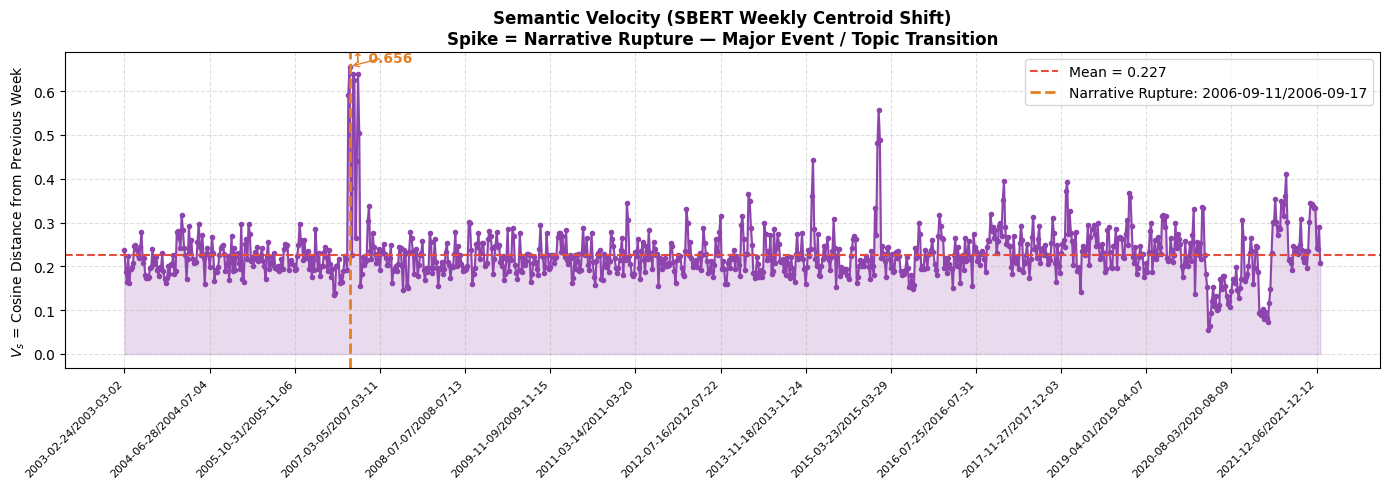

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(range(len(vel_df)), vel_df['semantic_velocity'], alpha=0.22, color='#9B59B6')
ax.plot(range(len(vel_df)), vel_df['semantic_velocity'],
        color='#8E44AD', linewidth=1.5, marker='o', markersize=3)
ax.axhline(vel_df['semantic_velocity'].mean(), color='#E74C3C', linestyle='--',
           label=f'Mean = {vel_df["semantic_velocity"].mean():.3f}')
rupture_idx = vel_df['semantic_velocity'].idxmax()
ax.axvline(rupture_idx, color='#E67E22', linewidth=2, linestyle='--',
           label=f'Narrative Rupture: {rupture_week}')
ax.annotate(f'↑ {max_vel:.3f}',
            xy=(rupture_idx, max_vel),
            xytext=(rupture_idx + 2, max_vel + 0.01),
            arrowprops=dict(arrowstyle='->', color='#E67E22'),
            fontsize=10, color='#E67E22', fontweight='bold')

step = max(1, len(vel_df)//14)
ax.set_xticks(range(0, len(vel_df), step))
ax.set_xticklabels(vel_df['week'].iloc[::step], rotation=45, ha='right', fontsize=8)
ax.set_title('Semantic Velocity (SBERT Weekly Centroid Shift)\n'
             'Spike = Narrative Rupture — Major Event / Topic Transition',
             fontsize=12, fontweight='bold')
ax.set_ylabel('$V_s$ = Cosine Distance from Previous Week')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('reports/deep_learning/semantic_velocity.png', dpi=150)
plt.show()

## 9. GDELT Verification — External News Correlation

In [13]:
import ast
from collections import Counter

gdelt_path = 'data/gdelt_processed.csv'
if not os.path.exists(gdelt_path):
    print('[SKIP] Run Notebook 04 first.')
else:
    gdelt_df = pd.read_csv(gdelt_path)
    gdelt_df['theme_list'] = gdelt_df['theme_list'].apply(
        lambda v: ast.literal_eval(v) if isinstance(v, str) else []
    )
    all_themes = Counter(t for row in gdelt_df['theme_list'] for t in row)
    top30_gdelt = set(t for t, _ in all_themes.most_common(30))

    print('Cluster ↔ GDELT Cross-Reference:')
    print('─' * 60)
    rows = []
    for c, terms in cluster_terms.items():
        matches = [t for t in terms
                   if any(t.lower() in gt.lower() or gt.lower() in t.lower()
                          for gt in top30_gdelt)]
        rows.append({'Topic': f'Topic {chr(65+c)}',
                     'Top Terms (SBERT K-Means)': ', '.join(terms[:5]),
                     'GDELT Theme Matches': ', '.join(matches) or '(indirect)'})
        print(f'  Topic {chr(65+c)}: {terms[:5]}')
        print(f'    GDELT: {matches if matches else "(indirect)"}')
    display(pd.DataFrame(rows))

Cluster ↔ GDELT Cross-Reference:
────────────────────────────────────────────────────────────
  Topic A: ['water', 'rain', 'drought', 'flood', 'weather']
    GDELT: (indirect)
  Topic B: ['new', 'farmers', 'cattle', 'rural', 'indigenous']
    GDELT: (indirect)
  Topic C: ['council', 'election', 'govt', 'government', 'mp']
    GDELT: ['government', 'mp', 'minister']
  Topic D: ['coronavirus', 'covid', 'vaccine', 'cases', 'flu']
    GDELT: (indirect)
  Topic E: ['iraq', 'china', 'trump', 'says', 'korea']
    GDELT: (indirect)
  Topic F: ['bushfire', 'blaze', 'fires', 'house', 'firefighters']
    GDELT: (indirect)
  Topic G: ['crash', 'death', 'dies', 'killed', 'dead']
    GDELT: ['killed', 'man', 'police']
  Topic H: ['market', 'price', 'industry', 'business', 'budget']
    GDELT: ['price']
  Topic I: ['australia', 'australian', 'sydney', 'nsw', 'melbourne']
    GDELT: (indirect)
  Topic J: ['interview', 'speaks', 'abc', 'news', 'drum']
    GDELT: (indirect)
  Topic K: ['health', 'hospit

,Topic,Top Terms (SBERT K-Means),GDELT Theme Matches
0,Topic A,"water, rain, drought, flood, weather",(indirect)
1,Topic B,"new, farmers, cattle, rural, indigenous",(indirect)
2,Topic C,"council, election, govt, government, mp","government, mp, minister"
3,Topic D,"coronavirus, covid, vaccine, cases, flu",(indirect)
4,Topic E,"iraq, china, trump, says, korea",(indirect)
5,Topic F,"bushfire, blaze, fires, house, firefighters",(indirect)
6,Topic G,"crash, death, dies, killed, dead","killed, man, police"
7,Topic H,"market, price, industry, business, budget",price
8,Topic I,"australia, australian, sydney, nsw, melbourne",(indirect)
9,Topic J,"interview, speaks, abc, news, drum",(indirect)


## 10. Model Comparison: TF-IDF vs LDA vs SBERT K-Means

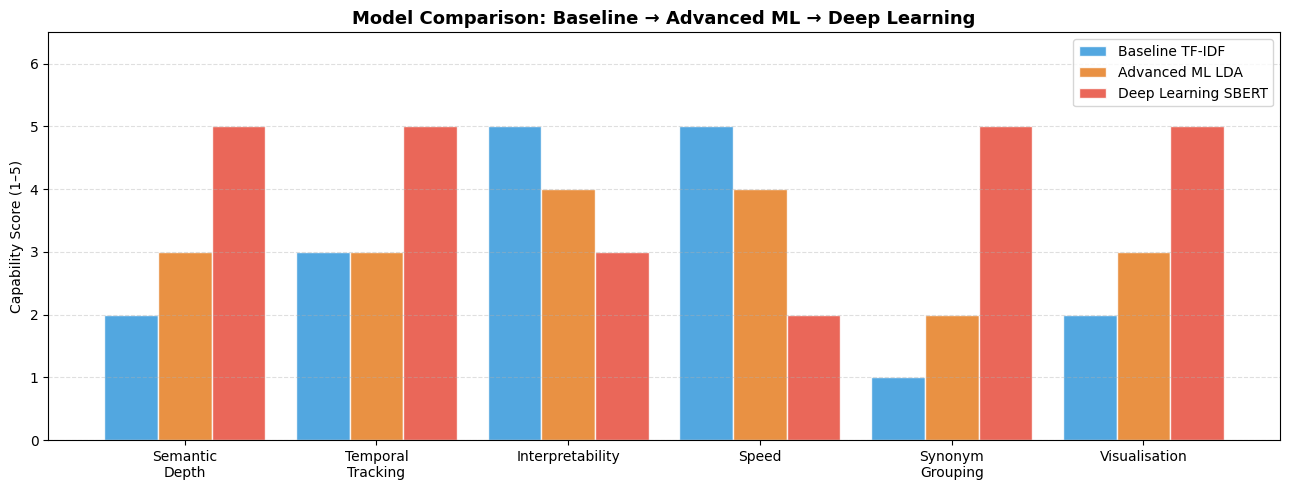

In [14]:
categories = ['Semantic\nDepth', 'Temporal\nTracking', 'Interpretability',
              'Speed', 'Synonym\nGrouping', 'Visualisation']
models = {
    'Baseline TF-IDF':    [2, 3, 5, 5, 1, 2],
    'Advanced ML LDA':    [3, 3, 4, 4, 2, 3],
    'Deep Learning SBERT':[5, 5, 3, 2, 5, 5],
}
colors = ['#3498DB', '#E67E22', '#E74C3C']

x = np.arange(len(categories))
w = 0.28
fig, ax = plt.subplots(figsize=(13, 5))
for i, (model, scores) in enumerate(models.items()):
    ax.bar(x + (i - 1) * w, scores, w, label=model,
           color=colors[i], alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 6.5)
ax.set_ylabel('Capability Score (1–5)')
ax.set_title('Model Comparison: Baseline → Advanced ML → Deep Learning',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('reports/deep_learning/model_comparison_chart.png', dpi=150)
plt.show()

## 11. Save Reports

In [15]:
summary = pd.DataFrame([{
    'Cluster': f'Topic {chr(65+c)}',
    'Size': int((df['cluster'] == c).sum()),
    'TopTerms': ', '.join(cluster_terms[c]),
} for c in range(best_k)])
summary.to_csv('reports/deep_learning/cluster_summary.csv', index=False)

with open('reports/deep_learning/verification_report.txt', 'w') as f:
    f.write('MODEL INTEGRITY REPORT — DEEP LEARNING (SBERT + K-Means)\n')
    f.write('=' * 60 + '\n')
    f.write(f'Model              : SBERT (all-MiniLM-L6-v2)\n')
    f.write(f'Embedding dim      : 384\n')
    f.write(f'UMAP               : 3D + 2D\n')
    f.write(f'Clustering         : K-Means K={best_k}\n')
    f.write(f'Documents          : {len(df):,}\n')
    f.write(f'Silhouette Score   : {sil_final:.4f}\n')
    f.write(f'Calinski-Harabasz  : {ch_score:.2f}\n')
    f.write(f'Max Sem Velocity   : {max_vel:.4f} (Week {rupture_week})\n')
    f.write('=' * 60 + '\n\nClusters:\n')
    for _, row in summary.iterrows():
        f.write(f"  {row['Cluster']} ({row['Size']:,} docs): {row['TopTerms']}\n")

print('\nAll reports saved to reports/deep_learning/')
print('\n=== DEEP LEARNING SUMMARY ===')
print(f'  Optimal K           : {best_k}')
print(f'  Silhouette Score    : {sil_final:.4f}')
print(f'  Calinski-Harabasz   : {ch_score:.2f}')
print(f'  Max Semantic Velocity: {max_vel:.4f} → Week {rupture_week}')
display(summary)


All reports saved to reports/deep_learning/

=== DEEP LEARNING SUMMARY ===
  Optimal K           : 13
  Silhouette Score    : 0.0226
  Calinski-Harabasz   : 454.89
  Max Semantic Velocity: 0.6563 → Week 2006-09-11/2006-09-17


,Cluster,Size,TopTerms
0,Topic A,2403,"water, rain, drought, flood, weather, cyclone,..."
1,Topic B,4718,"new, farmers, cattle, rural, indigenous, wa, f..."
2,Topic C,4488,"council, election, govt, government, mp, says,..."
3,Topic D,1399,"coronavirus, covid, vaccine, cases, flu, outbr..."
4,Topic E,3879,"iraq, china, trump, says, korea, iran, war, at..."
5,Topic F,1354,"bushfire, blaze, fires, house, firefighters, b..."
6,Topic G,3072,"crash, death, dies, killed, dead, man, car, po..."
7,Topic H,4991,"market, price, industry, business, budget, pay..."
8,Topic I,4660,"australia, australian, sydney, nsw, melbourne,..."
9,Topic J,4911,"interview, speaks, abc, news, drum, new, talks..."


## Summary

| Step | Method | Output |
|---|---|---|
| Encoding | SBERT `all-MiniLM-L6-v2` | 384-dim contextual embeddings |
| Reduction | UMAP (3D + 2D) | Visualisable low-dim projections |
| Clustering | K-Means (optimal K via Silhouette) | Topic A, B, C, … clusters |
| Growth Velocity | Monthly cluster count | Timeline of topic rise/fall |
| Semantic Velocity | Weekly centroid cosine distance | Narrative rupture detection |
| GDELT Verification | Theme cross-reference | External validation |

### Key Insight

A **spike in Semantic Velocity** indicates a real-world event caused the news corpus to suddenly shift topics — distinguishing a *transient social meme* (low velocity, returns to baseline) from a *structural narrative rupture* (sustained high velocity, topics permanently reorganise).

This output cross-referenced with GDELT's global theme signals provides the **strongest evidence layer** in the Dynamic Trend Detector framework.